# Project Overview:
This project aims to analyze customer behavior for a marketing dataset to gain insights into purchasing patterns, campaign effectiveness, and demographic influences on spending. By performing this analysis, we aim to answer several key business questions and help improve marketing strategies.
In following sections we define the question then run the code and after that explain the results

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('marketing_campaign (1).csv',sep='\t')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
data.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

## what is the frequency of Income

C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


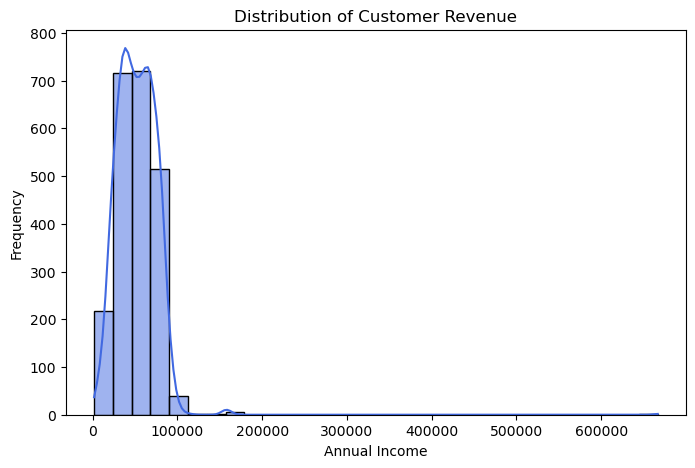

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(data["Income"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of Customer Revenue")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

The **Income** variable shows high variance and a wide spread of values.

Since the goal of this analysis is to focus on the majority of the population,  
extremely high income values (outliers) are excluded from the analysis.

In [6]:
data = data.dropna(subset=['Income'])
data = data[data['Income']<500000]

C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


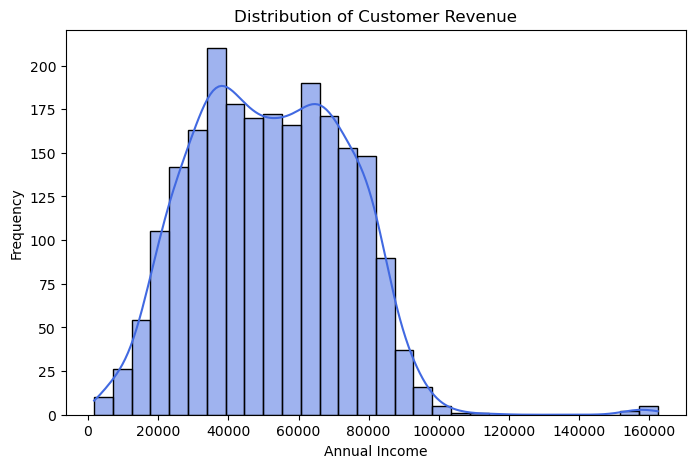

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data["Income"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of Customer Revenue")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

## How does purchase frequency vary across different marketing channels?

In [8]:
canales = {
    "Web": data["NumWebPurchases"].sum(),
    "Catalog": data["NumCatalogPurchases"].sum(),
    "Physical store": data["NumStorePurchases"].sum()
}

In [9]:
#convert the canales dictionary into two separate lists: one for the labels (keys) and one for the values
labels = list(canales.keys())
values = list(canales.values())

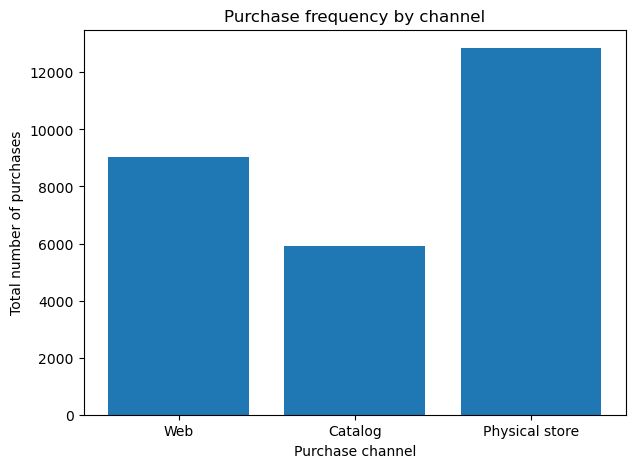

In [10]:
plt.figure(figsize=(7,5))
plt.bar(labels, values)
plt.title("Purchase frequency by channel")
plt.xlabel("Purchase channel")
plt.ylabel("Total number of purchases")
plt.show()

In [11]:
data[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].mean()

NumWebPurchases        4.085779
NumCatalogPurchases    2.671783
NumStorePurchases      5.802257
dtype: float64

### It is observed that customers make more purchases in the physical store, averaging 5.80 purchases, followed by online purchases with an average of 4.08 and catalog purchases with an average of 2.67.

---

## How does average spending differ across income levels for each category?

In [12]:
data["Income_group"] = pd.qcut(
    data["Income"],
    q=4,
    labels=["Low", "Medium-low", "Medium-high", "high"]
)

In [13]:
categories = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

In [15]:
#following code summarizes the average purchases in each category by income group, producing a table that makes it easy to compare behavior across income levels.
tabla = data.groupby("Income_group")[categories].mean().T

C:\Users\Sharif\AppData\Local\Temp\ipykernel_8700\823453036.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = data.groupby("Income_group")[categories].mean().T


<Figure size 1000x600 with 0 Axes>

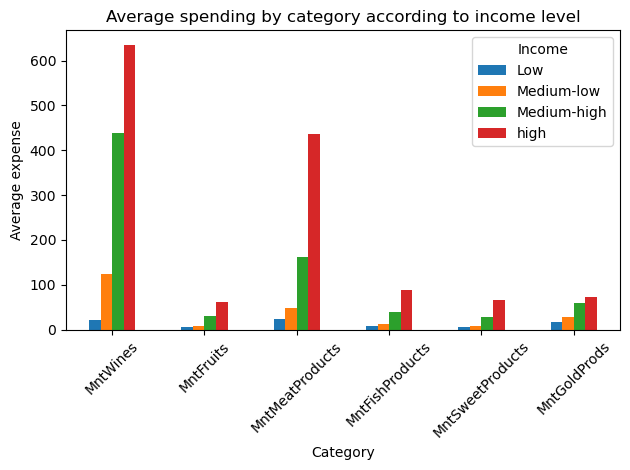

In [16]:
plt.figure(figsize=(10,6))
tabla.plot(kind="bar")
plt.title("Average spending by category according to income level")
plt.xlabel("Category")
plt.ylabel("Average expense")
plt.xticks(rotation=45)
plt.legend(title="Income")

plt.tight_layout()
plt.show()

### When analyzing the average costs by product category and according to income level, it is observed that high-income customers spend more on categories such as wine, meat, and fish, while low-income customers have a higher average expenditure on meat and wine.

---

## Is there a relationship between income and spending in each category?

The bar plot shows the correlation between Income and spending across different product categories.
It provides a high-level summary of how strongly each category is influenced by income.

In [26]:
categorias = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

In [27]:
income_corr = data[categorias + ['Income']].corr()['Income'].drop('Income').sort_values(ascending=False)
print("Correlation of spending with Income:\n", income_corr)

Correlation of spending with Income:
 MntMeatProducts     0.692465
MntWines            0.688269
MntSweetProducts    0.523746
MntFishProducts     0.520351
MntFruits           0.507959
MntGoldProds        0.389204
Name: Income, dtype: float64


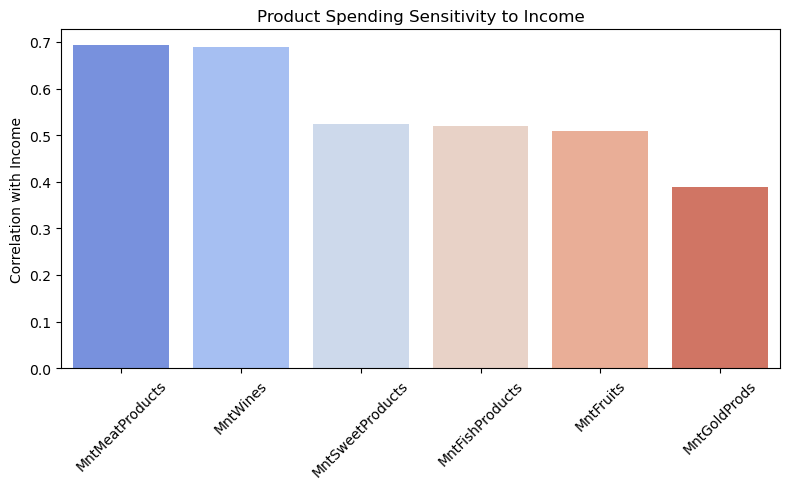

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x=income_corr.index, y=income_corr.values, palette='coolwarm')
plt.ylabel('Correlation with Income')
plt.title('Product Spending Sensitivity to Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The values range between 0 and 1, meaning all relationships are positive (as income increases, spending also increases), but the strength of the relationship varies. The correlation analysis shows that income has the strongest relationship with spending on meat and wine products, indicating these are more luxury-oriented items. Fruits, fish, and sweets show moderate correlations, suggesting broader consumption across income levels. Gold products have the weakest correlation, implying that factors other than income may drive purchasing behavior.
**Products with high correlation → suitable for targeting high-income customers
Products with low correlation → suitable for general marketing campaigns**

To further investigate these relationships, a FacetGrid scatter plot is used to visualize the actual distribution of Income versus spending within each category.

In [30]:
data_long = data.melt(
    id_vars="Income",
    value_vars=categories,
    var_name="category",
    value_name="spending"
)

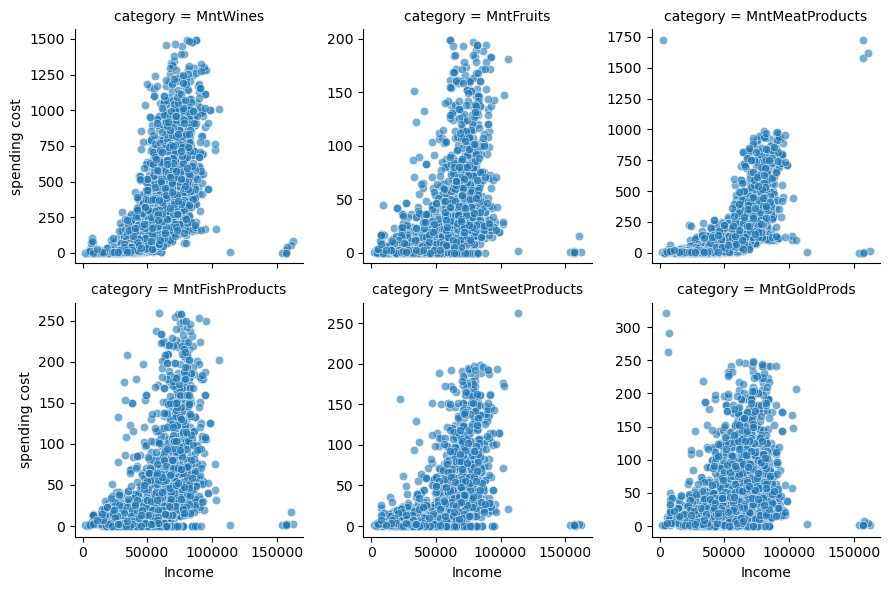

In [31]:
g = sns.FacetGrid(data_long, col="category", col_wrap=3, height=3, sharey=False)
g.map_dataframe(sns.scatterplot, x="Income", y="spending", alpha=0.6)
g.set_axis_labels("Income", "spending cost")
plt.show()

While the correlation plot summarizes the strength of the relationship, the scatter plots reveal the underlying patterns and variability in the data. Overall, the combination of both visualizations shows that although some categories exhibit a strong positive correlation with income, **the actual spending behavior varies within categories and is influenced by additional factors beyond income alone.**

---

## How does family structure influence purchasing?

In [32]:
data["NumChildren"] = data["Kidhome"] + data["Teenhome"]

In [33]:
data["Family_group"] = pd.cut(
    data["NumChildren"],
    bins=[-1, 0, 1, 10],
    labels=["Childless", "1 child", "2 or more children"]
)

In [34]:
categories = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

In [35]:
tabla = data.groupby("Family_group")[categories].mean().T

C:\Users\Sharif\AppData\Local\Temp\ipykernel_8700\2664121805.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = data.groupby("Family_group")[categories].mean().T


<Figure size 1000x600 with 0 Axes>

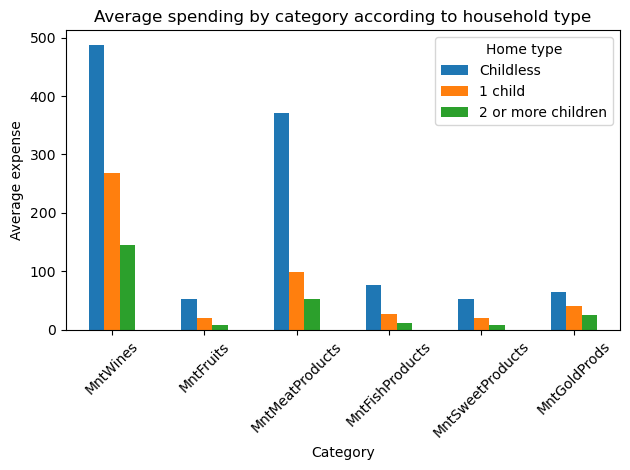

In [36]:
plt.figure(figsize=(10,6))
tabla.plot(kind="bar")

plt.title("Average spending by category according to household type")
plt.xlabel("Category")
plt.ylabel("Average expense")
plt.xticks(rotation=45)
plt.legend(title="Home type")

plt.tight_layout()
plt.show()

### Customers without children show higher interest in the meat and wine categories, and the same categories are also popular among families with two or more children.

---

## Which marketing campaigns are most effective?

In [37]:
camp_response_list = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

In [38]:
campaign_counts = data[camp_response_list].sum()

In [39]:
most_accepted_campaign = campaign_counts.idxmax()

In [40]:
print("The most accepted campaign is: ", most_accepted_campaign[8:])

The most accepted campaign is:  Cmp4


In [41]:
data_reshape = data[camp_response_list].melt(
    var_name="Campaign",
    value_name="Accepted"
)

<Axes: xlabel='Campaign', ylabel='count'>

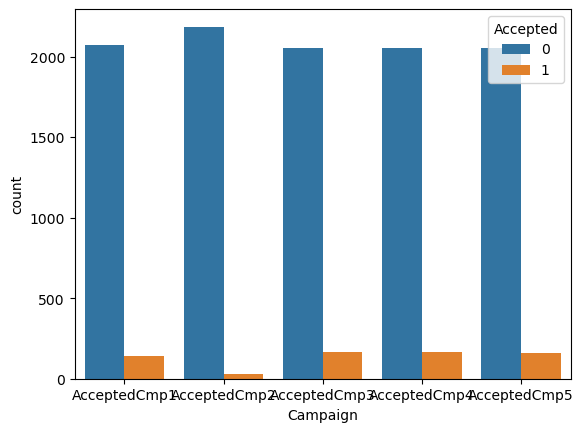

In [42]:
data_reshape["Accepted"] = data_reshape["Accepted"].astype(str)
sns.countplot(data=data_reshape, x="Campaign", hue="Accepted")

### the most effective campaign is no.4 

---

## Customer engagement over time:

In [43]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True)

In [44]:
data['Year'] = data['Dt_Customer'].dt.year

In [45]:
categorias = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
data['Total_Spend'] = data[categorias].sum(axis=1)

In [46]:
yearly_spend = data.groupby('Year')['Total_Spend'].mean().reset_index()

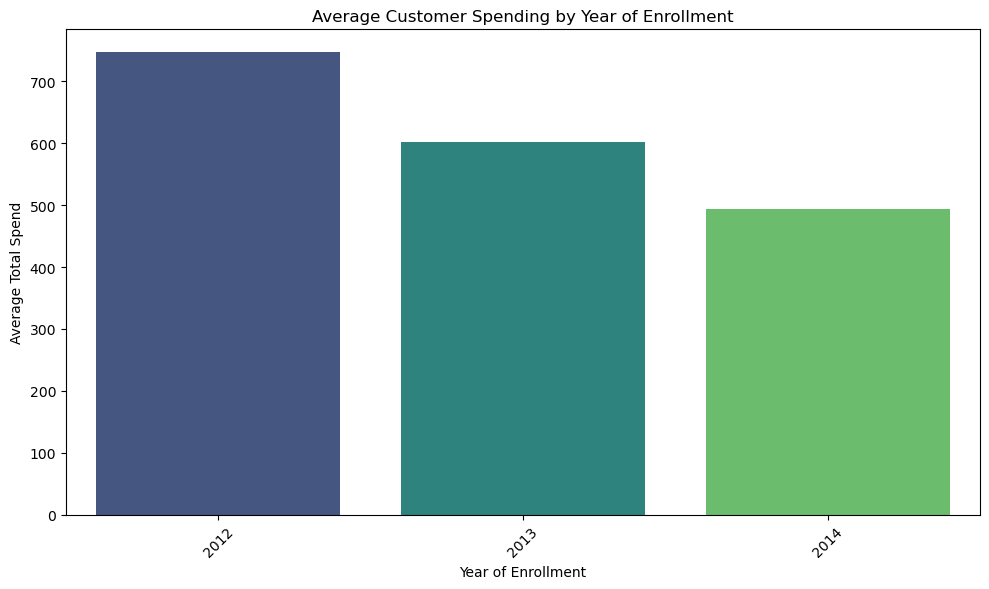

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(data=yearly_spend, x='Year', y='Total_Spend', palette='viridis')
plt.title('Average Customer Spending by Year of Enrollment')
plt.xlabel('Year of Enrollment')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### However, this pattern does not necessarily imply that newer customers are inherently less valuable. Since customers who enrolled earlier have had a longer relationship with the company, their higher spending may partly reflect greater customer tenure rather than differences in customer characteristics.

---

## Do recently enrolled customers prefer online or in-store purchases?

In [48]:
purchase_by_year = data.groupby('Year')[
    ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
].mean().reset_index()

In [49]:
purchase_long = purchase_by_year.melt(
    id_vars='Year',
    var_name='Channel',
    value_name='Average_Purchases'
)

C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a le

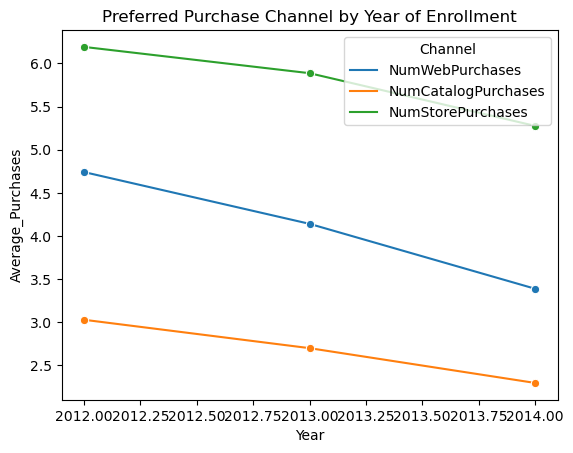

In [50]:
sns.lineplot(
    data=purchase_long,
    x='Year',
    y='Average_Purchases',
    hue='Channel',
    marker='o'
)
plt.title('Preferred Purchase Channel by Year of Enrollment')
plt.show()

In [52]:
new_customers = data[data['Year'] == data['Year'].max()]

new_customers[
    ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
].mean()

NumWebPurchases        3.388788
NumCatalogPurchases    2.296564
NumStorePurchases      5.276673
dtype: float64

### recently enrolled customers prefer store purchases 

---

## How do new and long-term customers differ in terms of spending, purchasing behavior, and marketing campaign engagement?

In [54]:
categorias = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']

In [55]:
data['Total_Spend'] = data[categorias].sum(axis=1)

In [58]:
data['Tenure_days'] = (pd.to_datetime("today") - data['Dt_Customer']).dt.days

In [59]:
data['Customer_type'] = pd.cut(
    data['Tenure_days'],
    bins=[0, 1000, 10000],
    labels=["New", "Long-term"]
)

In [61]:
data['Total_Purchases'] = data[
    ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
].sum(axis=1)

In [63]:
data['Segment'] = (
    data['Income_group'].astype(str) + "_" +
    data['Customer_type'].astype(str)
)

In [65]:
data['Campaign_Response'] = data[camp_response_list].sum(axis=1)

In [66]:
segmentation_summary = data.groupby('Segment').agg({
    'Total_Spend': 'mean',
    'Total_Purchases': 'mean',
    'Campaign_Response': 'mean'
}).sort_values(by='Total_Spend', ascending=False)

segmentation_summary

,Total_Spend,Total_Purchases,Campaign_Response
Segment,,,
high_Long-term,1359.994575,19.345389,0.741410
Medium-high_Long-term,757.741877,16.682310,0.231047
Medium-low_Long-term,231.315884,8.774368,0.142599
Low_Long-term,81.592058,5.449458,0.079422


---

In [ ]:
## 

In [68]:
def marketing_strategy(row):
    if row['Total_Spend'] > segmentation_summary['Total_Spend'].median():
        return "Premium offers / Luxury products"
    elif row['Campaign_Response'] > segmentation_summary['Campaign_Response'].median():
        return "Campaign-focused promotions"
    else:
        return "Discount-based retention strategy"

segmentation_summary['Strategy'] = segmentation_summary.apply(marketing_strategy, axis=1)
segmentation_summary

,Total_Spend,Total_Purchases,Campaign_Response,Strategy
Segment,,,,
high_Long-term,1359.994575,19.345389,0.741410,Premium offers / Luxury products
Medium-high_Long-term,757.741877,16.682310,0.231047,Premium offers / Luxury products
Medium-low_Long-term,231.315884,8.774368,0.142599,Discount-based retention strategy
Low_Long-term,81.592058,5.449458,0.079422,Discount-based retention strategy


### Customers are segmented based on income level and tenure, and their behavior is analyzed in terms of spending, purchases, and campaign response. Based on these insights, personalized marketing strategies are assigned to each segment, such as premium offers for high-value customers and discount-based retention strategies for low-engagement groups.